Source: sc-best-practices book: Heumos, L., Schaar, A.C., Lance, C. et al. Best practices for single-cell analysis across modalities. Nat Rev Genet (2023). https://doi.org/10.1038/s41576-023-00586-w

# preprocessing steps
- doublet detection
- quality control
- normalization
- feature selection
- dimensionality reduction

# Preprocessing and visualization

source: https://www.sc-best-practices.org/preprocessing_visualization/quality_control.html

## 6. Quality Control

### 6.2. Environment setup and data

In [39]:
import numpy as np
import scanpy as sc
import seaborn as sns
from scipy.stats import median_abs_deviation
from matplotlib import pyplot as plt

sc.settings.verbosity = 0
sc.settings.set_figure_params(
    dpi=80,
    facecolor="white",
    frameon=False,
)

In [2]:
# (own code)
import os

adata = sc.read_h5ad(os.path.join("..", "datasets", "GSM6592049_M2.h5ad"))
adata

AnnData object with n_obs × n_vars = 4992 × 36386
    obs: 'in_tissue', 'array_row', 'array_col', 'suspension_type', 'assay_ontology_term_id', 'Sample_ID', 'organism_ontology_term_id', 'sex_ontology_term_id', 'development_stage_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'disease_ontology_term_id', 'tissue_type', 'tissue_ontology_term_id', 'pathologist_annotation', 'B-cells', 'CAFs', 'Cancer Epithelial', 'Endothelial', 'Myeloid', 'Normal Epithelial', 'PVL', 'T-cells', 'stereoscope_annotation', 'cell_type_ontology_term_id', 'is_primary_data', 'treatment', 'donor_id', 'cell_type', 'assay', 'disease', 'organism', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid'
    var: 'feature_types', 'genome', 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type', 'ensemble_id'
    uns: 'citation', 'schema_reference', 'schema_version', 'spatial', 'title'
    obsm: 'spatial'

In [3]:
adata.var_names_make_unique()
adata

AnnData object with n_obs × n_vars = 4992 × 36386
    obs: 'in_tissue', 'array_row', 'array_col', 'suspension_type', 'assay_ontology_term_id', 'Sample_ID', 'organism_ontology_term_id', 'sex_ontology_term_id', 'development_stage_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'disease_ontology_term_id', 'tissue_type', 'tissue_ontology_term_id', 'pathologist_annotation', 'B-cells', 'CAFs', 'Cancer Epithelial', 'Endothelial', 'Myeloid', 'Normal Epithelial', 'PVL', 'T-cells', 'stereoscope_annotation', 'cell_type_ontology_term_id', 'is_primary_data', 'treatment', 'donor_id', 'cell_type', 'assay', 'disease', 'organism', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid'
    var: 'feature_types', 'genome', 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type', 'ensemble_id'
    uns: 'citation', 'schema_reference', 'schema_version', 'spatial', 'title'
    obsm: 'spatial'

### 6.3. Filtering low quality cells

[W]e define cell quality control (QC) threshold. Cell QC is typically performed on the following three QC covariates:

- The number of counts per barcode (count depth)
- The number of genes per barcode
- The fraction of counts from mitochondrial genes per barcode


However, as datasets grow in size [...] it might be worth considering automatic thresholding via MAD (median absolute deviations). The MAD [...] describes a robust statistic of the variability of the metric. Similar to [Germain et al., 2020], we mark cells as outliers if they differ by 5 MADs which is a relatively permissive filtering strategy. We want to highlight that it might be reasonable to re-assess the filtering after annotation of cells.

In [4]:
# mitochondrial genes
adata.var["mt"] = adata.var_names.str.startswith("MT-")
# ribosomal genes
adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL"))
# hemoglobin genes.
adata.var["hb"] = adata.var_names.str.contains("^HB[^(P)]")

In [5]:
print(adata.var["mt"].sum(), "mitochondrial genes")
print(adata.var["ribo"].sum(), "ribosomal genes")
print(adata.var["hb"].sum(), "hemoglobin genes")

13 mitochondrial genes
107 ribosomal genes
12 hemoglobin genes


In [6]:
# calculate the QC covariates or metric
# it can also calculate the proportions of counts for specific gene populations
sc.pp.calculate_qc_metrics(adata, qc_vars=["mt", "ribo", "hb"], inplace=True, percent_top=[20], log1p=True)
adata

AnnData object with n_obs × n_vars = 4992 × 36386
    obs: 'in_tissue', 'array_row', 'array_col', 'suspension_type', 'assay_ontology_term_id', 'Sample_ID', 'organism_ontology_term_id', 'sex_ontology_term_id', 'development_stage_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'disease_ontology_term_id', 'tissue_type', 'tissue_ontology_term_id', 'pathologist_annotation', 'B-cells', 'CAFs', 'Cancer Epithelial', 'Endothelial', 'Myeloid', 'Normal Epithelial', 'PVL', 'T-cells', 'stereoscope_annotation', 'cell_type_ontology_term_id', 'is_primary_data', 'treatment', 'donor_id', 'cell_type', 'assay', 'disease', 'organism', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_

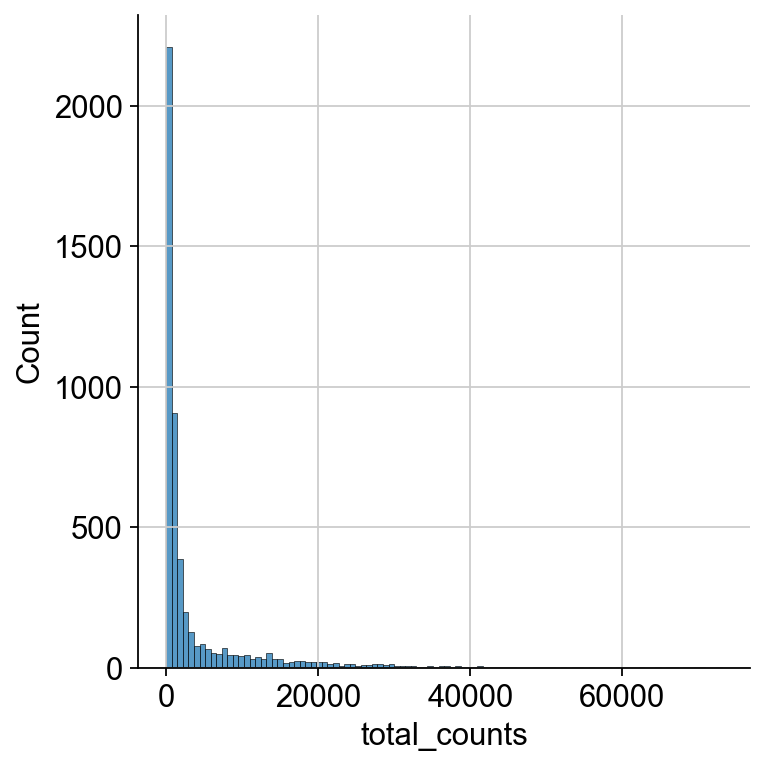

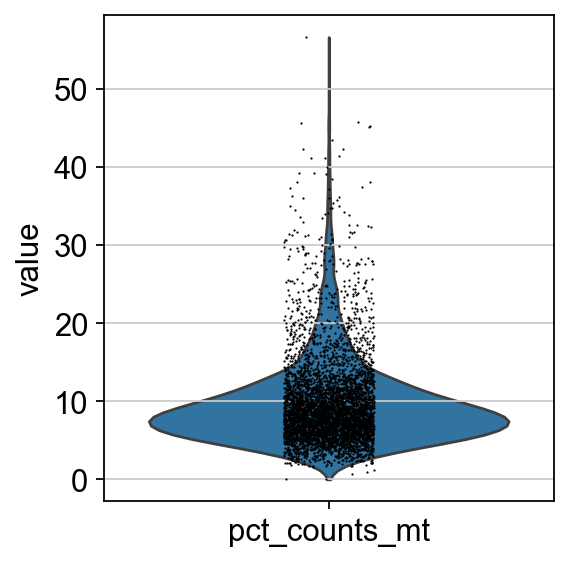

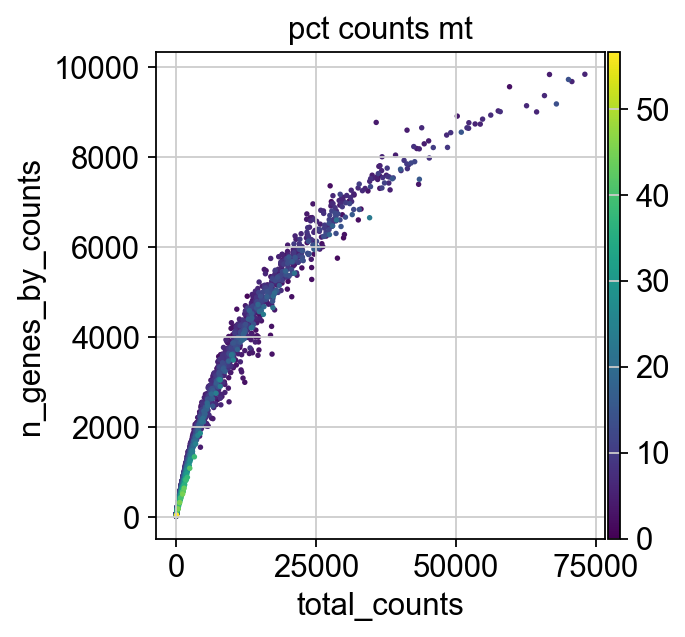

In [7]:
#  plot the three QC covariates n_genes_by_counts, total_counts and pct_counts_mt per sample

p1 = sns.displot(adata.obs["total_counts"], bins=100, kde=False)
# sc.pl.violin(adata, 'total_counts')
p2 = sc.pl.violin(adata, "pct_counts_mt")
p3 = sc.pl.scatter(adata, "total_counts", "n_genes_by_counts", color="pct_counts_mt")

[W]e will show QC with automatic thresholding and filtering based on MAD.

In [8]:
# First, we define a function that takes a metric, i.e. a column in .obs and the number of MADs (nmad) that is still permissive within the filtering strategy.
def is_outlier(adata, metric: str, nmads: int):
    M = adata.obs[metric]
    outlier = (M < np.median(M) - nmads * median_abs_deviation(M)) | (np.median(M) + nmads * median_abs_deviation(M) < M)
    return outlier

In [9]:
# We now apply this function to the log1p_total_counts, log1p_n_genes_by_counts and pct_counts_in_top_20_genes QC covariates each with a threshold of 5 MADs.
adata.obs["outlier"] = (
    is_outlier(adata, "log1p_total_counts", 5)
    | is_outlier(adata, "log1p_n_genes_by_counts", 5)
    | is_outlier(adata, "pct_counts_in_top_20_genes", 5)
)
adata.obs.outlier.value_counts()

outlier
False    4830
True      162
Name: count, dtype: int64

In [10]:
# pct_counts_Mt is filtered with 3 MADs. Additionally, cells with a percentage of mitochondrial counts exceeding 8 % are filtered out.
adata.obs["mt_outlier"] = is_outlier(adata, "pct_counts_mt", 3) | (
    adata.obs["pct_counts_mt"] > 15 # 8 default
)
adata.obs.mt_outlier.value_counts()

mt_outlier
False    4385
True      607
Name: count, dtype: int64

In [11]:
# We now filter our AnnData object based on these two additional columns.
print(f"Total number of cells: {adata.n_obs}")
adata = adata[(~adata.obs.outlier) & (~adata.obs.mt_outlier)].copy()

print(f"Number of cells after filtering of low quality cells: {adata.n_obs}")

Total number of cells: 4992
Number of cells after filtering of low quality cells: 4323


In [12]:
print(adata.var["mt"].sum(), "mitochondrial genes")
print(adata.var["ribo"].sum(), "ribosomal genes")
print(adata.var["hb"].sum(), "hemoglobin genes")

13 mitochondrial genes
107 ribosomal genes
12 hemoglobin genes


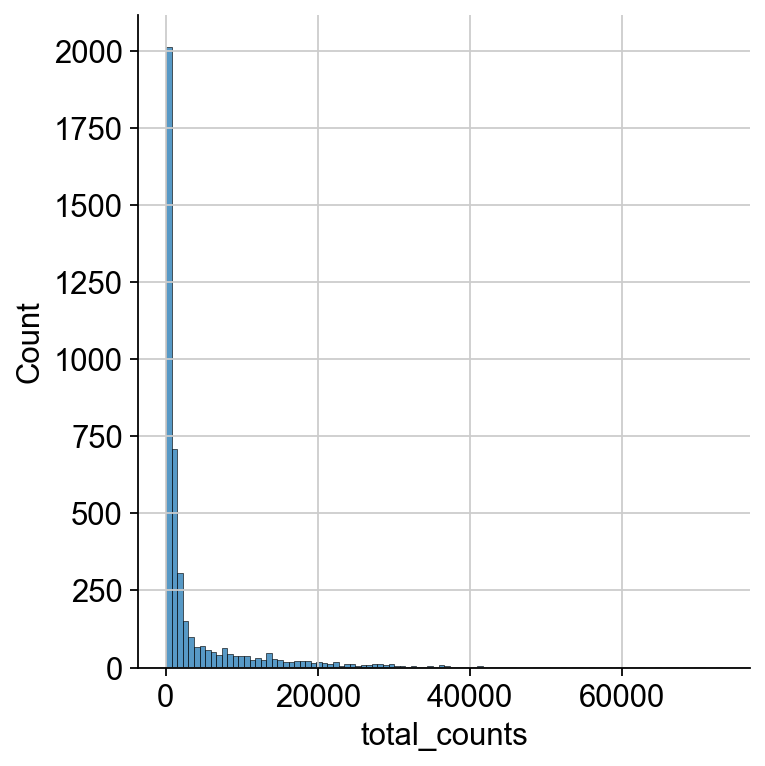

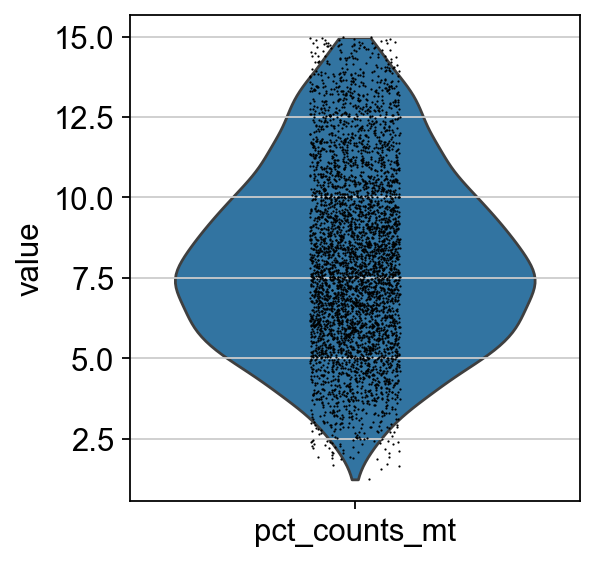

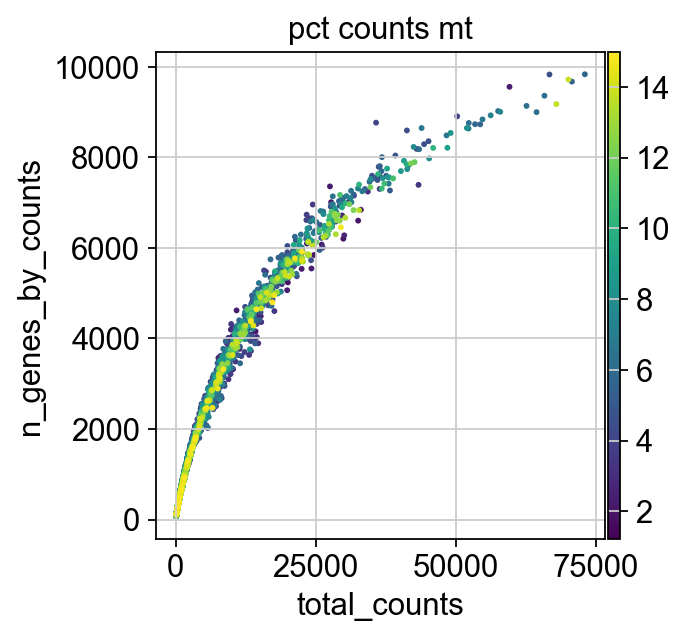

In [13]:
p1 = sns.displot(adata.obs["total_counts"], bins=100, kde=False)
p2 = sc.pl.violin(adata, "pct_counts_mt")
p3 = sc.pl.scatter(adata, "total_counts", "n_genes_by_counts", color="pct_counts_mt")

### 6.4. Correction of ambient RNA

In [14]:
import logging

import anndata2ri
import rpy2.rinterface_lib.callbacks as rcb
import rpy2.robjects as ro
from rpy2.robjects import pandas2ri

rcb.logger.setLevel(logging.ERROR)

# New recommended way:
#pandas2ri.activate()
anndata2ri.activate()

%load_ext rpy2.ipython

# Load the rpy2 IPython extension (only in Jupyter)
# get_ipython().run_line_magic('load_ext', 'rpy2.ipython')


Error importing in API mode: ImportError('On Windows, cffi mode "ANY" is only "ABI".')
Trying to import in ABI mode.
C:\Users\rebec\AppData\Local\Temp\ipykernel_9688\2409816188.py:12: DeprecationWarning: The global conversion available with activate() is deprecated and will be removed in the next major release. Use a local converter.
  anndata2ri.activate()


In [15]:
#os.environ["R_ENVIRON_USER"] = ""  # Clear if something custom is set
#os.environ["R_DEFAULT_ENCODING"] = "utf-8"

In [16]:
%%R
options(encoding = "UTF-8")
Sys.setlocale(category = "LC_ALL", locale = "English_United States.UTF-8")
library(SoupX)


    an issue that caused a segfault when used with rpy2:
    https://github.com/rstudio/reticulate/pull/1188
    Make sure that you use a version of that package that includes
    the fix.
    

In addition: Warning message:
In Sys.setlocale(category = "LC_ALL", locale = "English_United States.UTF-8") :
  using locale code page other than 1252 may cause problems


SoupX can be used [...] by manually defining clusters.

In [17]:
adata_pp = adata.copy()
sc.pp.normalize_total(adata_pp)
sc.pp.log1p(adata_pp)

Next, we compute the principle components of the data to obtain a lower dimensional representation. This representation is then used to generate a neighbourhood graph of the data and run leiden clustering on the KNN-graph. We add the clusters as soupx_groups to .obs and save them as a vector.

In [18]:
sc.pp.pca(adata_pp)
sc.pp.neighbors(adata_pp)
sc.tl.leiden(adata_pp, key_added="soupx_groups")

# Preprocess variables for SoupX
soupx_groups = adata_pp.obs["soupx_groups"]

del adata_pp

c:\Users\rebec\miniforge3\envs\mapra\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\rebec\AppData\Local\Temp\ipykernel_9688\1811796492.py:3: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata_pp, key_added="soupx_groups")


In [19]:
cells = adata.obs_names
genes = adata.var_names
data = adata.X.T

In [20]:
adata_raw = sc.read_h5ad(os.path.join("..", "datasets", "GSM6592049_M2.h5ad"))
adata_raw.var_names_make_unique()
data_tod = adata_raw.X.T

del adata_raw

In [22]:
# Assuming data and data_tod are scipy sparse matrices
data_dense = data.toarray()
data_tod_dense = data_tod.toarray()

In [25]:
%%R -i data_dense -i data_tod_dense -i genes -i cells -i soupx_groups -o out 

# specify row and column names of data
rownames(data_dense) = genes
colnames(data_dense) = cells
# ensure correct sparse format for table of counts and table of droplets
data <- as(data_dense, "sparseMatrix")
data_tod <- as(data_tod_dense, "sparseMatrix")

# Generate SoupChannel Object for SoupX 
sc = SoupChannel(data_tod_dense, data_dense, calcSoupProfile = FALSE)

# Add extra meta data to the SoupChannel object
soupProf = data.frame(row.names = rownames(data_dense), est = rowSums(data_dense)/sum(data_dense), counts = rowSums(data_dense))
sc = setSoupProfile(sc, soupProf)
# Set cluster information in SoupChannel
sc = setClusters(sc, soupx_groups)

# Estimate contamination fraction
sc  = autoEstCont(sc, doPlot=FALSE)
# Infer corrected table of counts and rount to integer
out = adjustCounts(sc, roundToInt = TRUE)

3507 genes passed tf-idf cut-off and 2484 soup quantile filter.  Taking the top 100.
Using 652 independent estimates of rho.
Estimated global rho of 0.45
Expanding counts from 11 clusters to 4323 cells.
In addition: Warning messages:
1: In setContaminationFraction(sc, contEst, forceAccept = forceAccept) :
  Estimated contamination is very high (0.45).
2: In sparseMatrix(i = out@i[w] + 1, j = out@j[w] + 1, x = out@x[w],  :
  'giveCsparse' is deprecated; setting repr="T" for you


SoupX successfully inferred corrected counts, which we can now store as an additional layer. In all following analysis steps, we would like to use the SoupX corrected count matrix, so we overwrite .X with the soupX corrected matrix.

In [28]:
from scipy.sparse import csc_matrix

# Ensure out is NumPy and correctly oriented
out = ro.conversion.rpy2py(ro.globalenv['out'])  # if not already done
out_sparse = csc_matrix(out.T)  # Transpose to match (cells x genes)

adata.layers["counts"] = adata.X
adata.layers["soupX_counts"] = out_sparse
adata.X = adata.layers["soupX_counts"]

In [29]:
print(f"Total number of genes: {adata.n_vars}")

# Min 20 cells - filters out 0 count genes
sc.pp.filter_genes(adata, min_cells=20)
print(f"Number of genes after cell filter: {adata.n_vars}")

Total number of genes: 36386
Number of genes after cell filter: 14395


### 6.5. Doublet Detection

Doublets are defined as two cells that are sequenced under the same cellular barcode, for example, if they were captured in the same droplet.

In [30]:
%%R
library(Seurat)
library(scater)
library(scDblFinder)
library(BiocParallel)

Lade nötiges Paket: SeuratObject
Lade nötiges Paket: sp

Attache Paket: 'SeuratObject'

Die folgenden Objekte sind maskiert von 'package:base':

    intersect, t

Lade nötiges Paket: SingleCellExperiment
Lade nötiges Paket: SummarizedExperiment
Lade nötiges Paket: MatrixGenerics
Lade nötiges Paket: matrixStats

Attache Paket: 'MatrixGenerics'

Die folgenden Objekte sind maskiert von 'package:matrixStats':

    colAlls, colAnyNAs, colAnys, colAvgsPerRowSet, colCollapse,
    colCounts, colCummaxs, colCummins, colCumprods, colCumsums,
    colDiffs, colIQRDiffs, colIQRs, colLogSumExps, colMadDiffs,
    colMads, colMaxs, colMeans2, colMedians, colMins, colOrderStats,
    colProds, colQuantiles, colRanges, colRanks, colSdDiffs, colSds,
    colSums2, colTabulates, colVarDiffs, colVars, colWeightedMads,
    colWeightedMeans, colWeightedMedians, colWeightedSds,
    colWeightedVars, rowAlls, rowAnyNAs, rowAnys, rowAvgsPerColSet,
    rowCollapse, rowCounts, rowCummaxs, rowCummins, rowCumprods,
  

In [33]:
data_mat = adata.X.T.toarray()

In [34]:
%%R -i data_mat -o doublet_score -o doublet_class

set.seed(123)
sce = scDblFinder(
    SingleCellExperiment(
        list(counts=data_mat),
    ) 
)
doublet_score = sce$scDblFinder.score
doublet_class = sce$scDblFinder.class

Creating ~3459 artificial doublets...
Dimensional reduction
Evaluating kNN...
Training model...
iter=0, 448 cells excluded from training.
iter=1, 515 cells excluded from training.
iter=2, 520 cells excluded from training.
Threshold found:0.528
369 (8.5%) doublets called
In addition: Warning message:
In .checkSCE(sce) :
  Some cells in `sce` have an extremely low read counts; note that these could trigger errors and might best be filtered out


In [35]:
adata.obs["scDblFinder_score"] = doublet_score
adata.obs["scDblFinder_class"] = doublet_class
adata.obs.scDblFinder_class.value_counts()

scDblFinder_class
singlet    3954
doublet     369
Name: count, dtype: int64

## 7. Normalization

This chapter will introduce the reader to three different normalization techniques, the shifted logarithm transformation, scran normalization and analytic approximation of Pearson residuals. The shifted logarithm works beneficial for stabilizing variance for subsequent dimensionality reduction and identification of differentially expressed genes. Scran was extensively tested and used for batch correction tasks and analytic Pearson residuals are well suited for selecting biologically variable genes and identification of rare cell types.

shifted logarithm --> spatial

scran --> sc


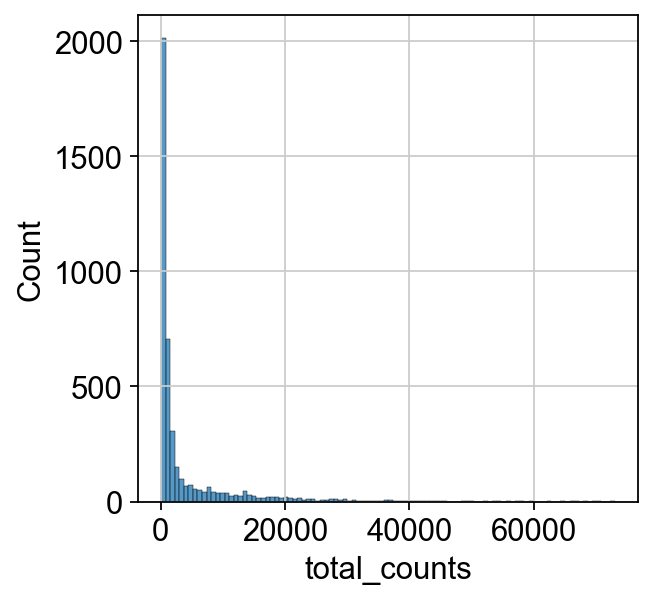

In [36]:
p1 = sns.histplot(adata.obs["total_counts"], bins=100, kde=False)

### 7.2. Shifted Logarithm

In [43]:
scales_counts = sc.pp.normalize_total(adata, target_sum=None, inplace=False)
# log1p transform
adata.layers["log1p_norm"] = sc.pp.log1p(scales_counts["X"], copy=True)

scales_counts_2 = sc.pp.normalize_total(adata, target_sum=1e4, inplace=False)
# log1p transform
adata.layers["log1p_norm_2"] = sc.pp.log1p(scales_counts_2["X"], copy=True)

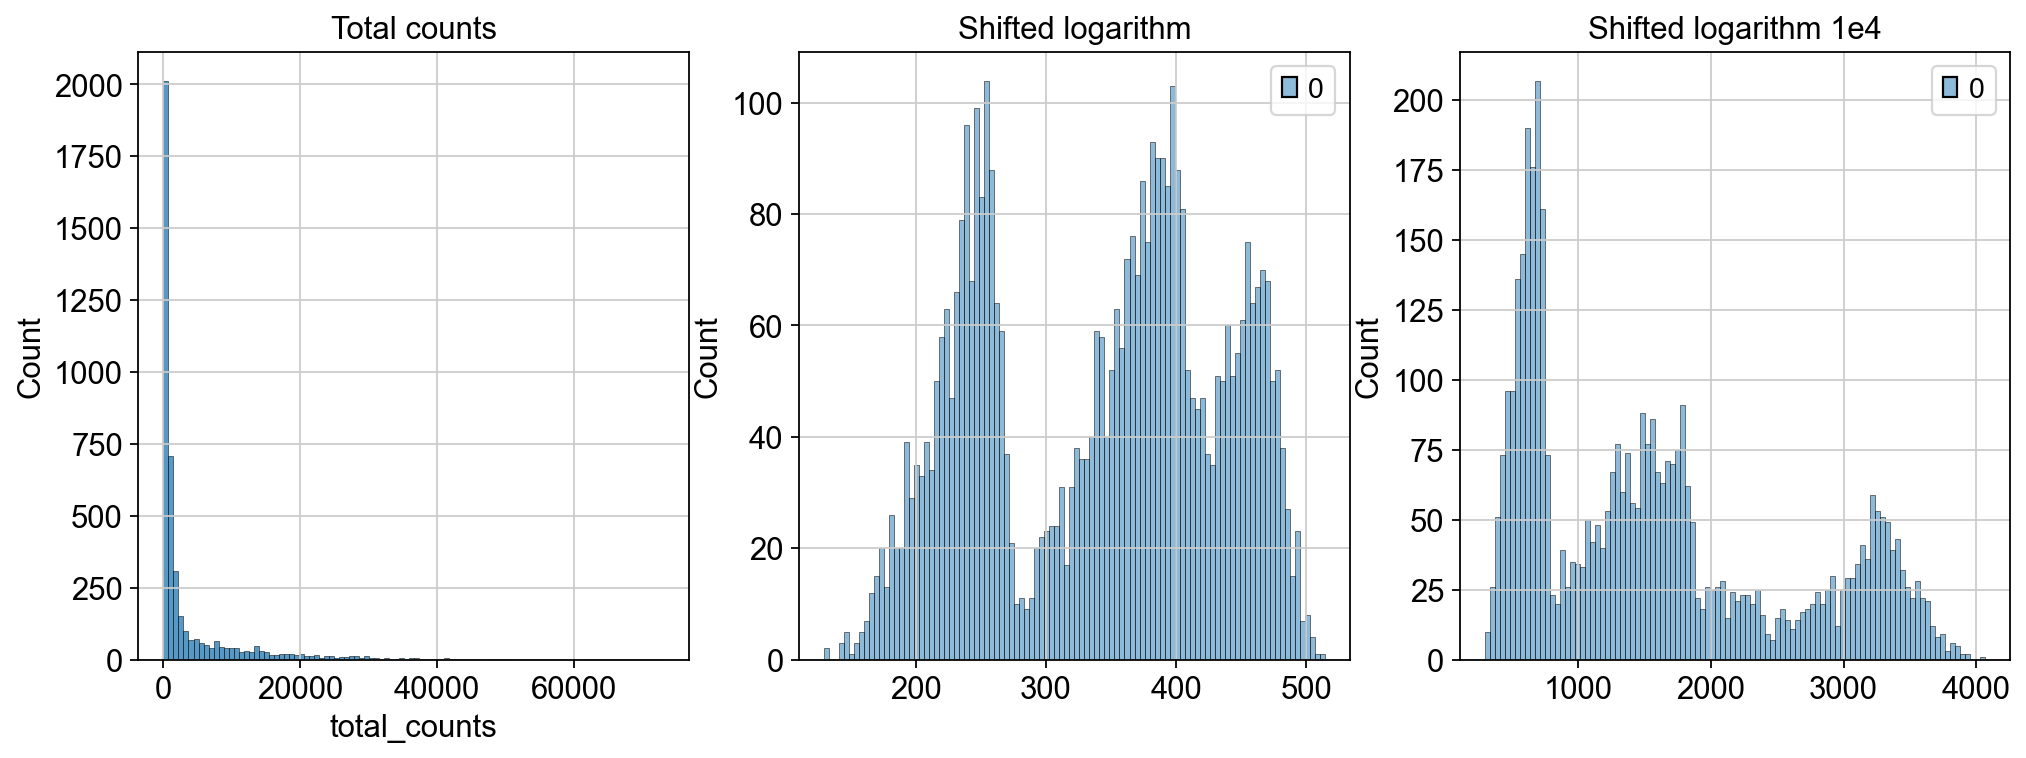

In [45]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
p1 = sns.histplot(adata.obs["total_counts"], bins=100, kde=False, ax=axes[0])
axes[0].set_title("Total counts")
p2 = sns.histplot(adata.layers["log1p_norm"].sum(1), bins=100, kde=False, ax=axes[1])
axes[1].set_title("Shifted logarithm")
p3 = sns.histplot(adata.layers["log1p_norm_2"].sum(1), bins=100, kde=False, ax=axes[2])
axes[2].set_title("Shifted logarithm 1e4")
plt.show()

### 7.3. Scran’s pooling-based size factor estimation

In [53]:
from scipy.sparse import csr_matrix

In [46]:
%%R
library(scran)
library(BiocParallel)

In [47]:
# Preliminary clustering for differentiated normalisation
adata_pp = adata.copy()
sc.pp.normalize_total(adata_pp)
sc.pp.log1p(adata_pp)
sc.pp.pca(adata_pp, n_comps=15)
sc.pp.neighbors(adata_pp)
sc.tl.leiden(adata_pp, key_added="groups")

In [ ]:
data_mat = adata_pp.X.T
# convert to CSC if possible. See https://github.com/MarioniLab/scran/issues/70

ro.globalenv["data_mat"] = data_mat
ro.globalenv["input_groups"] = adata_pp.obs["groups"]

del adata_pp

In [51]:
%%R -o size_factors

size_factors = sizeFactors(
    computeSumFactors(
        SingleCellExperiment(
            list(counts=data_mat)), 
            clusters = input_groups,
            min.mean = 0.1,
            BPPARAM = MulticoreParam()
    )
)

In addition: Warning message:
In MulticoreParam() :
  MulticoreParam() not supported on Windows, use SnowParam()


In [56]:
adata.obs["size_factors"] = size_factors
scran = adata.X / adata.obs["size_factors"].values[:, None]
log_scran = np.log1p(scran)  # safe for both dense or sparse
adata.layers["scran_normalization"] = csr_matrix(log_scran)

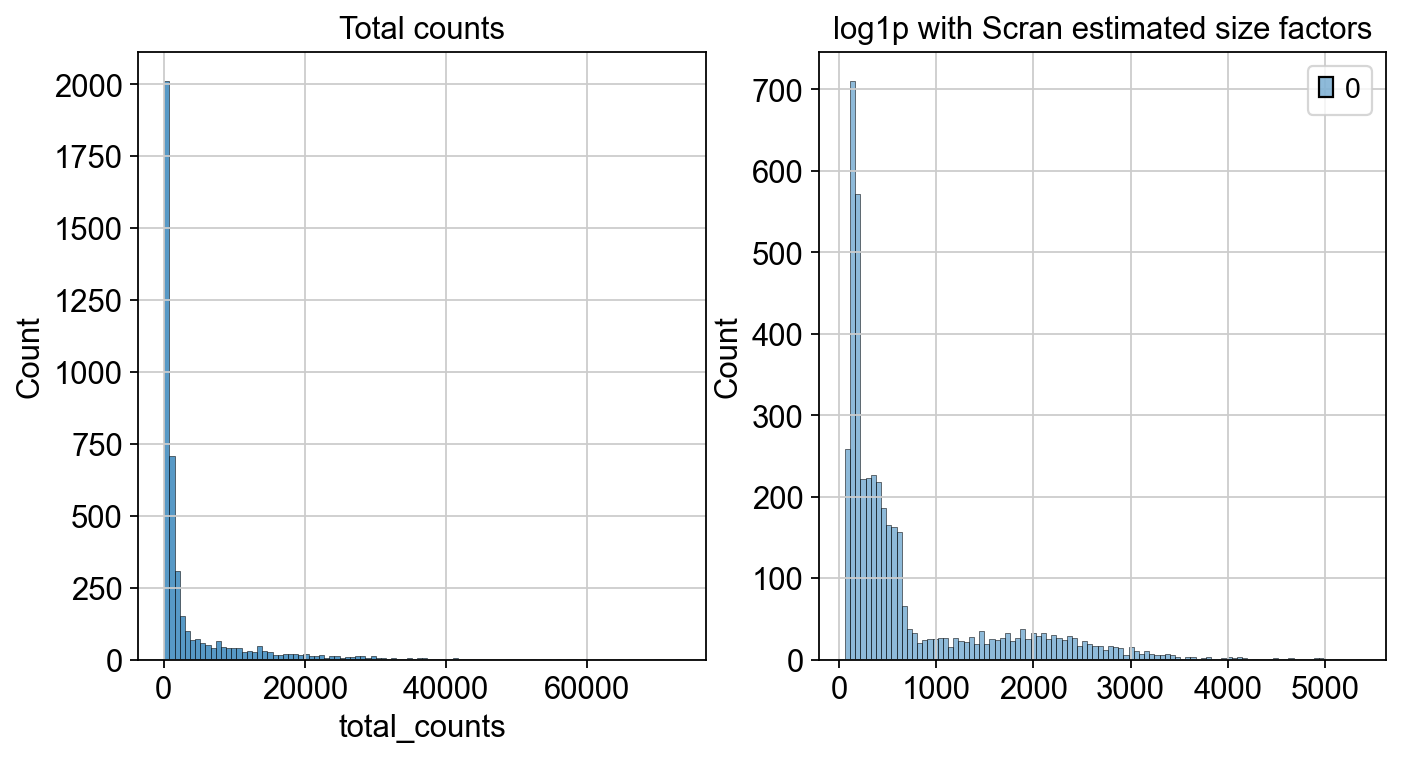

In [57]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
p1 = sns.histplot(adata.obs["total_counts"], bins=100, kde=False, ax=axes[0])
axes[0].set_title("Total counts")
p2 = sns.histplot(
    adata.layers["scran_normalization"].sum(1), bins=100, kde=False, ax=axes[1]
)
axes[1].set_title("log1p with Scran estimated size factors")
plt.show()

# 8. Feature Selection

[...] feature selection which aims to exclude uninformative genes which might not represent meaningful biological variation across samples.

In [60]:
%%R
library(scry)

In [61]:
ro.globalenv["adata"] = adata

ValueError: Converting pandas "Category" series to R factor is only possible when categories are strings.

In [ ]:
%%R
sce = devianceFeatureSelection(adata, assay="X")

In [ ]:
binomial_deviance = ro.r("rowData(sce)$binomial_deviance").T

In [ ]:
idx = binomial_deviance.argsort()[-4000:]
mask = np.zeros(adata.var_names.shape, dtype=bool)
mask[idx] = True

adata.var["highly_deviant"] = mask
adata.var["binomial_deviance"] = binomial_deviance

In [ ]:
sc.pp.highly_variable_genes(adata, layer="scran_normalization")

In [ ]:
ax = sns.scatterplot(
    data=adata.var, x="means", y="dispersions", hue="highly_deviant", s=5
)
ax.set_xlim(None, 1.5)
ax.set_ylim(None, 3)
plt.show()

In [ ]:
adata.write("s4d8_quality_control.h5ad")


### 6.6 Key Takeaways

- Filtering of poor-quality cells should be based on median absolute deviations with lenient cutoffs to avoid bias against smaller subpopulations.

- Feature-based filtering does not show benefits for downstream tasks.

- Doublets can be efficiently detected with tools like scDblFinder.

- Doublet detection methods should not be run on aggregated scRNA-seq data representing multiple batches.
